In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = "cpu"
print("Using device:", device)

WORLD_NAME = "Realistic"


Using device: cpu


In [125]:
def simulate_realistic_world(n=10000):
    # -----------------------------
    # DEMOGRAPHICS
    # -----------------------------
    race = np.random.choice([0,1,2], n, p=[0.6,0.25,0.15])   # 0 = majority, 1 = mid group, 2 = minority
    gender = np.random.choice([0,1], n)                       # 0 = female, 1 = male
    age = np.clip(np.random.normal(50,12,n), 18, 90)

    # -----------------------------
    # SOCIO-ECONOMIC STATUS (SES)
    # race -> SES (structural inequality)
    # -----------------------------
    ses = (
        0.4*(race==0)   # advantaged group
        + 0.0*(race==1) # neutral group
        - 0.6*(race==2) # disadvantaged minority group
    ) + np.random.normal(0,0.4,n)

    # -----------------------------
    # LIFESTYLE SCORE (influenced by SES + age)
    # -----------------------------
    lifestyle = (
        0.6*ses
        - 0.02*(age-50)
        + np.random.normal(0,0.5,n)
    )

    # -----------------------------
    # BMI influenced by lifestyle + gender
    # -----------------------------
    bmi = (
        27
        - 1.3*lifestyle
        + 1.0*(gender==1)           # males slightly higher BMI
        + np.random.normal(0,3,n)
    )

    # -----------------------------
    # TRUE glucose physiology
    # -----------------------------
    glucose_true = (
        95
        + 1.2*(bmi-27)
        - 2.5*lifestyle
        + 0.4*((age-50)/10)
        + np.random.normal(0,8,n)
    )

    # -----------------------------
    # TRUE HbA1c physiology
    # -----------------------------
    hba1c_true = (
        5.4
        + 0.11*(bmi-27)
        - 0.12*lifestyle
        + 0.05*((age-50)/10)
        + np.random.normal(0,0.25,n)
    )

    # -----------------------------
    # TRUE diabetes label (ground truth)
    # -----------------------------
    logit = -7 + 0.06*glucose_true + 1.2*(hba1c_true - 5.4)
    prob = 1/(1+np.exp(-logit))
    diabetes_true = np.random.binomial(1, prob)

    # ============================================================
    # MEASUREMENT BIAS
    # ============================================================

    glucose_meas = glucose_true.copy()
    hba1c_meas = hba1c_true.copy()

    # Race 2 gets glucose UNDER-estimated (measurement bias)
    glucose_meas[race == 2] -= 15

    # Females get HbA1c OVER-estimated
    hba1c_meas[gender == 0] += 0.25

    # SES-related measurement noise (low SES = worse measurement quality)
    glucose_meas += np.random.normal(0, 5 + 3*(ses < -0.3), n)
    hba1c_meas   += np.random.normal(0, 0.15 + 0.07*(ses < -0.3), n)

    # ============================================================
    # LABEL BIAS (SAFE VERSION)
    # ============================================================

    diabetes_label = diabetes_true.copy()

    # --- Race 2 underdiagnosis: reduce true positives by ~30%
    mask_r2 = (race==2) & (diabetes_true==1)
    drop = np.random.binomial(1, 0.30, mask_r2.sum())   # 30% censorship
    diabetes_label[mask_r2] = np.maximum(0, diabetes_label[mask_r2] - drop)

    # --- Female overdiagnosis: flip some 0 → 1 (~15%)
    mask_f = (gender==0) & (diabetes_true==0)
    add = np.random.binomial(1, 0.15, mask_f.sum())
    diabetes_label[mask_f] = np.minimum(1, diabetes_label[mask_f] + add)

    # return final dataframe
    return pd.DataFrame({
        "race": race,
        "gender": gender,
        "age": age,
        "ses": ses,
        "bmi": bmi,
        "glucose_measured": glucose_meas,
        "hba1c_measured": hba1c_meas,
        "diabetes_true": diabetes_true,
        "diabetes_label": diabetes_label
    })


In [126]:
df = simulate_realistic_world(10000)

feature_cols = ["glucose_measured", "hba1c_measured", "age", "bmi"]
X = df[feature_cols]
y = df["diabetes_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train prevalence:", y_train.mean())
print("Test prevalence:", y_test.mean())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


Train prevalence: 0.29175
Test prevalence: 0.2935


In [127]:
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.long)

X_test_t  = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=32, shuffle=True)

test_loader = DataLoader(TensorDataset(X_test_t, y_test_t),
                         batch_size=32, shuffle=False)


In [128]:
class MLP(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=32):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, x):
        return self.model(x)


In [129]:
def train_epoch(model, train_dataloader, optimizer, loss_fn):
    losses = []
    correct_predictions = 0

    for features, labels in train_dataloader:
        output = model(features)
        optimizer.zero_grad()
        loss = loss_fn(output, labels)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        predicted = output.argmax(dim=1)
        correct_predictions += (predicted == labels).sum().item()

    acc = 100 * correct_predictions / len(train_dataloader.dataset)
    return np.mean(losses), acc


def evaluate(model, dataloader, loss_fn):
    losses = []
    correct_predictions = 0

    with torch.no_grad():
        for features, labels in dataloader:
            output = model(features)
            loss = loss_fn(output, labels)
            losses.append(loss.item())
            predicted = output.argmax(dim=1)
            correct_predictions += (predicted == labels).sum().item()

    acc = 100 * correct_predictions / len(dataloader.dataset)
    return np.mean(losses), acc


def train(model, train_dataloader, val_dataloader, optimizer, n_epochs, loss_fn):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(n_epochs):
        model.train()
        tr_loss, tr_acc = train_epoch(model, train_dataloader, optimizer, loss_fn)

        model.eval()
        val_loss, val_acc = evaluate(model, val_dataloader, loss_fn)

        train_losses.append(tr_loss)
        val_losses.append(val_loss)
        train_accs.append(tr_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{n_epochs}: train_acc={tr_acc:.2f}, val_acc={val_acc:.2f}")

    return train_losses, val_losses, train_accs, val_accs


def plot(train_losses, val_losses, train_accs, val_accs, title):
    plt.figure()
    plt.plot(train_losses)
    plt.plot(val_losses)
    plt.legend(["train_loss", "val_loss"])
    plt.title(title + " Loss")

    plt.figure()
    plt.plot(train_accs)
    plt.plot(val_accs)
    plt.legend(["train_acc", "val_acc"])
    plt.title(title + " Accuracy")


Epoch 1/20: train_acc=69.33, val_acc=71.80
Epoch 2/20: train_acc=72.17, val_acc=71.80
Epoch 3/20: train_acc=72.39, val_acc=71.80
Epoch 4/20: train_acc=72.54, val_acc=71.95
Epoch 5/20: train_acc=72.46, val_acc=72.30
Epoch 6/20: train_acc=72.72, val_acc=72.15
Epoch 7/20: train_acc=72.49, val_acc=72.15
Epoch 8/20: train_acc=72.46, val_acc=72.50
Epoch 9/20: train_acc=72.61, val_acc=71.95
Epoch 10/20: train_acc=72.59, val_acc=72.15
Epoch 11/20: train_acc=72.41, val_acc=72.00
Epoch 12/20: train_acc=72.53, val_acc=71.75
Epoch 13/20: train_acc=72.42, val_acc=72.00
Epoch 14/20: train_acc=72.60, val_acc=72.10
Epoch 15/20: train_acc=72.59, val_acc=72.35
Epoch 16/20: train_acc=72.60, val_acc=72.05
Epoch 17/20: train_acc=72.71, val_acc=71.70
Epoch 18/20: train_acc=72.58, val_acc=72.00
Epoch 19/20: train_acc=72.65, val_acc=72.05
Epoch 20/20: train_acc=72.76, val_acc=71.85


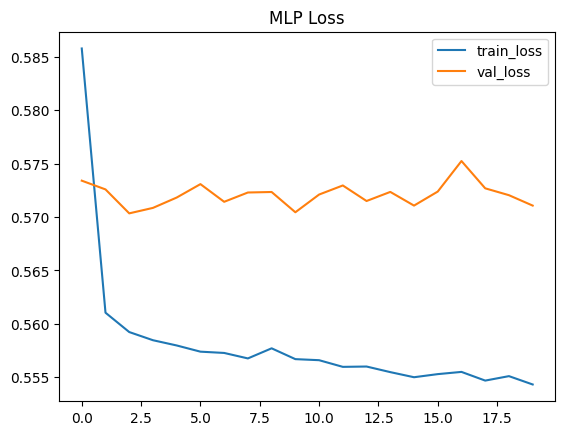

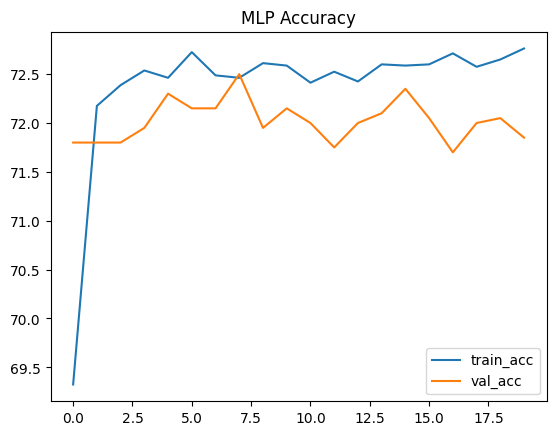

In [130]:
model = MLP().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses, val_losses, train_accs, val_accs = train(
    model, train_loader, test_loader, optimizer, 20, loss_fn
)

plot(train_losses, val_losses, train_accs, val_accs, "MLP")


In [133]:
model.eval()
with torch.no_grad():
    logits = model(X_test_t)
    mlp_pred = logits.argmax(dim=1).cpu().numpy()
    mlp_probs = logits.softmax(dim=1)[:,1].cpu().numpy()

print("MLP accuracy:", accuracy_score(y_test, mlp_pred))
print("MLP AUC:", roc_auc_score(y_test, mlp_probs))


MLP accuracy: 0.719
MLP AUC: 0.6608638934402018


In [134]:
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_probs = lr.predict_proba(X_test)[:,1]

print("LR accuracy:", accuracy_score(y_test, lr_pred))
print("LR AUC:", roc_auc_score(y_test, lr_probs))


LR accuracy: 0.7205
LR AUC: 0.6627531404058926


In [135]:
def fairness_by_group(y_true, y_pred, groups):
    results = {}
    for g in sorted(groups.unique()):
        mask = (groups == g)
        tn, fp, fn, tp = confusion_matrix(y_true[mask], y_pred[mask], labels=[0,1]).ravel()

        results[g] = {
            "FPR": fp/(fp+tn) if (fp+tn)>0 else np.nan,
            "FNR": fn/(fn+tp) if (fn+tp)>0 else np.nan,
            "TPR": tp/(tp+fn) if (tp+fn)>0 else np.nan,
            "TNR": tn/(tn+fp) if (tn+fp)>0 else np.nan,
        }

    return pd.DataFrame(results).T


In [136]:
mlp_pred_adj = (mlp_probs > 0.30).astype(int)

print(fairness_by_group(y_test, mlp_pred_adj, race_test))
print(fairness_by_group(y_test, mlp_pred_adj, gender_test))


        FPR       FNR       TPR       TNR
0  0.430639  0.376404  0.623596  0.569361
1  0.443836  0.338028  0.661972  0.556164
2  0.392694  0.382022  0.617978  0.607306
        FPR       FNR       TPR       TNR
0  0.419492  0.367347  0.632653  0.580508
1  0.436879  0.368601  0.631399  0.563121


In [137]:
race_test = df.loc[X_test.index, "race"]
gender_test = df.loc[X_test.index, "gender"]

lr_race_fairness = fairness_by_group(y_test, lr_pred, race_test)
lr_gender_fairness = fairness_by_group(y_test, lr_pred, gender_test)

mlp_race_fairness = fairness_by_group(y_test, mlp_pred, race_test)
mlp_gender_fairness = fairness_by_group(y_test, mlp_pred, gender_test)

print("=== LR Fairness by Race ===")
print(lr_race_fairness)

print("\n=== LR Fairness by Gender ===")
print(lr_gender_fairness)

print("\n=== MLP Fairness by Race ===")
print(mlp_race_fairness)

print("\n=== MLP Fairness by Gender ===")
print(mlp_gender_fairness)


=== LR Fairness by Race ===
        FPR       FNR       TPR       TNR
0  0.041405  0.832432  0.167568  0.958595
1  0.060109  0.867133  0.132867  0.939891
2  0.016000  0.918919  0.081081  0.984000

=== LR Fairness by Gender ===
        FPR       FNR       TPR       TNR
0  0.055988  0.820290  0.179710  0.944012
1  0.029870  0.896694  0.103306  0.970130

=== MLP Fairness by Race ===
        FPR       FNR       TPR       TNR
0  0.096612  0.724324  0.275676  0.903388
1  0.125683  0.706294  0.293706  0.874317
2  0.040000  0.810811  0.189189  0.960000

=== MLP Fairness by Gender ===
        FPR       FNR       TPR       TNR
0  0.108865  0.736232  0.263768  0.891135
1  0.081818  0.723140  0.276860  0.918182


In [138]:
def compute_equal_opportunity(fairness_df):
    return float(fairness_df["TPR"].max() - fairness_df["TPR"].min())


In [139]:
EO_LR_gender = compute_equal_opportunity(lr_gender_fairness)
EO_LR_race   = compute_equal_opportunity(lr_race_fairness)

EO_MLP_gender = compute_equal_opportunity(mlp_gender_fairness)
EO_MLP_race   = compute_equal_opportunity(mlp_race_fairness)

print("EO (LR) Gender:", EO_LR_gender)
print("EO (LR) Race:", EO_LR_race)
print("EO (MLP) Gender:", EO_MLP_gender)
print("EO (MLP) Race:", EO_MLP_race)


EO (LR) Gender: 0.07640435980356929
EO (LR) Race: 0.08648648648648649
EO (MLP) Gender: 0.013091388190202446
EO (MLP) Race: 0.1045171045171045


In [140]:
realistic_world_summary = {
    "world_name": WORLD_NAME,
    "LR_accuracy": accuracy_score(y_test, lr_pred),
    "LR_AUROC": roc_auc_score(y_test, lr_probs),
    "LR_EO_gender": EO_LR_gender,
    "LR_EO_race": EO_LR_race,
    "MLP_accuracy": accuracy_score(y_test, mlp_pred),
    "MLP_AUROC": roc_auc_score(y_test, mlp_probs),
    "MLP_EO_gender": EO_MLP_gender,
    "MLP_EO_race": EO_MLP_race
}

realistic_world_summary


{'world_name': 'Realistic',
 'LR_accuracy': 0.7205,
 'LR_AUROC': 0.6627531404058926,
 'LR_EO_gender': 0.07640435980356929,
 'LR_EO_race': 0.08648648648648649,
 'MLP_accuracy': 0.719,
 'MLP_AUROC': 0.6608638934402018,
 'MLP_EO_gender': 0.013091388190202446,
 'MLP_EO_race': 0.1045171045171045}